<a href="https://colab.research.google.com/github/Krishishah7/ai-learning-series/blob/main/02_deep_learning_foundations/18_model_saving_and_loading.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Model Saving and Loading

Training deep learning models can take a significant amount of time. Instead of training the same model every time, TensorFlow allows us to save the trained model to disk.

The saved model can later be loaded and used for evaluation or prediction without repeating the training process.

This is an essential step before deploying a deep learning model in real-world applications.

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
X = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
], dtype=float)

y = np.array([
    [0],
    [0],
    [0],
    [1]
], dtype=float)

In [3]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(2,)),
    tf.keras.layers.Dense(8, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

In [4]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [5]:
history = model.fit(
    X,
    y,
    epochs=100,
    verbose=0
)

In [6]:
loss, accuracy = model.evaluate(X, y)

print("Loss:", loss)
print("Accuracy:", accuracy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 0.7500 - loss: 0.6435
Loss: 0.643531858921051
Accuracy: 0.75


In [7]:
model.save("my_first_model.keras")

print("Model Saved Successfully!")

Model Saved Successfully!


In [8]:
loaded_model = tf.keras.models.load_model("my_first_model.keras")

print("Model Loaded Successfully!")

Model Loaded Successfully!


In [9]:
loaded_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8)              │            24 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101 (408.00 B)

 Trainable params: 33 (132.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 68 (276.00 B)

In [10]:
predictions = loaded_model.predict(X)

predicted_classes = (predictions >= 0.5).astype(int)

predicted_classes

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


array([[0],
       [0],
       [1],
       [1]])

In [11]:
results = pd.DataFrame({

    "Input 1": X[:,0].astype(int),

    "Input 2": X[:,1].astype(int),

    "Actual": y.flatten().astype(int),

    "Probability": np.round(predictions.flatten(),4),

    "Predicted": predicted_classes.flatten()

})

results

,Input 1,Input 2,Actual,Probability,Predicted
0,0,0,0,0.4577,0
1,0,1,0,0.4024,0
2,1,0,0,0.5956,1
3,1,1,1,0.5815,1


In [12]:
model.save_weights("model_weights.weights.h5")

print("Weights Saved Successfully!")

Weights Saved Successfully!


In [13]:
new_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(2,)),
    tf.keras.layers.Dense(8, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

new_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

new_model.load_weights("model_weights.weights.h5")

print("Weights Loaded Successfully!")

Weights Loaded Successfully!


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [14]:
loss, accuracy = new_model.evaluate(X, y)

print("Loss:", loss)
print("Accuracy:", accuracy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 254ms/step - accuracy: 0.7500 - loss: 0.6435
Loss: 0.643531858921051
Accuracy: 0.75


In [15]:
comparison = pd.DataFrame({

    "Method":[
        "model.save()",
        "save_weights()"
    ],

    "Saves":[
        "Architecture + Weights + Optimizer",
        "Only Weights"
    ],

    "Use Case":[
        "Deployment",
        "Transfer Learning / Continue Training"
    ]

})

comparison

,Method,Saves,Use Case
0,model.save(),Architecture + Weights + Optimizer,Deployment
1,save_weights(),Only Weights,Transfer Learning / Continue Training


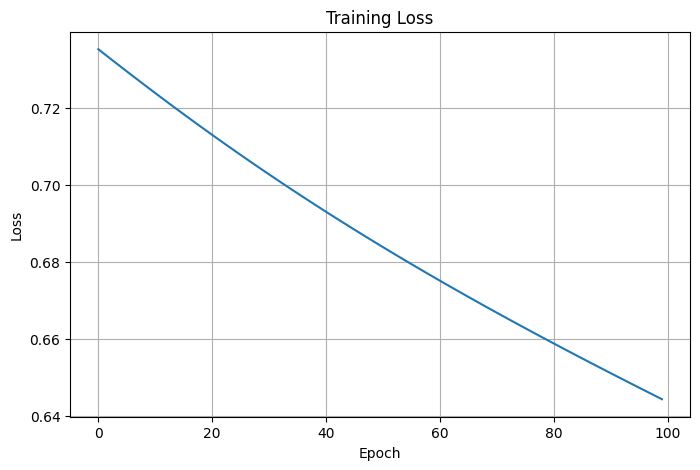

In [16]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"])

plt.title("Training Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.grid()

plt.show()

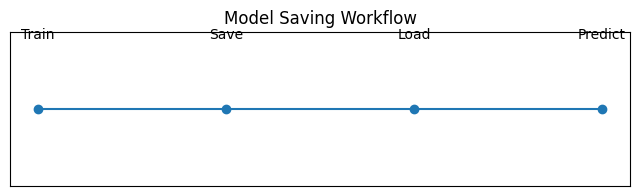

In [17]:
steps = [

    "Train",

    "Save",

    "Load",

    "Predict"

]

plt.figure(figsize=(8,2))

plt.plot(
    range(len(steps)),
    [1]*len(steps),
    marker="o"
)

for i, step in enumerate(steps):

    plt.text(
        i,
        1.05,
        step,
        ha="center"
    )

plt.xticks([])

plt.yticks([])

plt.title("Model Saving Workflow")

plt.show()